# Entraînement & Sauvegarde — Classifieur de Prompt (USE + Logistic Regression)

Ce notebook entraîne le classifieur qui transforme un **prompt utilisateur**
en un **label d'activité** (`rest`, `walk`, `run_jog`, ou `other`).

Pipeline : `phrase → embedding USE (512D) → Logistic Regression → label`

Le modèle est ensuite sauvegardé (`prompt_classifier.pkl`) pour être réutilisé
directement dans le pipeline d'inférence final, sans avoir à le réentraîner.


## 1. Configuration & Imports

In [1]:
import logging
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import tensorflow_hub as hub
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger(__name__)

# ── Constantes ────────────────────────────────────────────────────────────────
USE_URL       = "https://tfhub.dev/google/universal-sentence-encoder/4"
DATA_PATH     = Path("training_phrases.csv")
OUTPUT_DIR    = Path("saved_models")
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_PATH    = OUTPUT_DIR / "prompt_classifier.pkl"

LABEL_MAPPING = {"rest": 0, "walk": 1, "run_jog": 2, "other": 3}
INV_MAPPING   = {v: k for k, v in LABEL_MAPPING.items()}
LABEL_NAMES   = list(LABEL_MAPPING.keys())

TEST_SIZE    = 0.2
RANDOM_STATE = 42
LR_MAX_ITER  = 1000
LR_C         = 1.0

print("Configuration OK.")



Configuration OK.


## 2. Chargement de Universal Sentence Encoder

In [2]:
log.info("Chargement de USE depuis %s ...", USE_URL)
embed = hub.load(USE_URL)
log.info("USE chargé.")

# Démo rapide
demo = embed(["I am going for a walk"]).numpy()
print("Shape d'un embedding :", demo.shape)


23:10:42 [INFO] Chargement de USE depuis https://tfhub.dev/google/universal-sentence-encoder/4 ...
23:10:42 [INFO] Using C:\Users\adril\AppData\Local\Temp\tfhub_modules to cache modules.


23:10:42 [WARNING] From D:\IMDS\MALMO\.venv\Lib\site-packages\tensorflow_hub\resolver.py:120: The name tf.gfile.MakeDirs is deprecated. Please use tf.io.gfile.makedirs instead.



23:10:42 [WARNING] From D:\IMDS\MALMO\.venv\Lib\site-packages\tensorflow_hub\module_v2.py:126: The name tf.saved_model.load_v2 is deprecated. Please use tf.compat.v2.saved_model.load instead.

23:10:46 [INFO] Fingerprint not found. Saved model loading will continue.
23:10:46 [INFO] path_and_singleprint metric could not be logged. Saved model loading will continue.
23:10:46 [INFO] USE chargé.


Shape d'un embedding : (1, 512)


## 3. Chargement et validation des phrases d'entraînement

In [3]:
if not DATA_PATH.exists():
    log.error("Fichier introuvable : %s", DATA_PATH)
    sys.exit(1)

df = pd.read_csv(DATA_PATH)

required_cols = {"phrase", "label"}
missing = required_cols - set(df.columns)
if missing:
    log.error("Colonnes manquantes dans le CSV : %s", missing)
    sys.exit(1)

before = len(df)
df = df.dropna(subset=["phrase", "label"])
dropped = before - len(df)
if dropped:
    log.warning("%d ligne(s) supprimée(s) (valeurs manquantes).", dropped)

valid_mask = df["label"].isin(LABEL_MAPPING)
unknown = df.loc[~valid_mask, "label"].unique().tolist()
if unknown:
    log.warning("Labels inconnus ignorés : %s", unknown)
df = df[valid_mask].reset_index(drop=True)
df["label_id"] = df["label"].map(LABEL_MAPPING)

log.info("Données chargées : %d phrases, %d classes.", len(df), df["label"].nunique())
print(df["label"].value_counts())


23:10:46 [INFO] Données chargées : 324 phrases, 4 classes.


label
walk       82
rest       81
run_jog    81
other      80
Name: count, dtype: int64


## 4. Calcul des embeddings USE

In [4]:
log.info("Calcul des embeddings pour %d phrases ...", len(df))
embeddings = embed(df["phrase"].tolist()).numpy()   # (N, 512)
labels     = df["label_id"].values
log.info("Embeddings calculés : %s", embeddings.shape)


23:10:46 [INFO] Calcul des embeddings pour 324 phrases ...
23:10:46 [INFO] Embeddings calculés : (324, 512)


## 5. Split train/test & entraînement

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels,
)
log.info("Split : %d train / %d test.", len(X_train), len(X_test))

clf = LogisticRegression(
    max_iter=LR_MAX_ITER,
    C=LR_C,
    solver="lbfgs",
    random_state=RANDOM_STATE,
)
clf.fit(X_train, y_train)
log.info("Entraînement terminé.")


23:10:46 [INFO] Split : 259 train / 65 test.
23:10:46 [INFO] Entraînement terminé.


## 6. Évaluation

── Rapport de classification ─────────────────────
              precision    recall  f1-score   support

        rest       0.94      1.00      0.97        16
        walk       0.94      1.00      0.97        17
     run_jog       1.00      1.00      1.00        16
       other       1.00      0.88      0.93        16

    accuracy                           0.97        65
   macro avg       0.97      0.97      0.97        65
weighted avg       0.97      0.97      0.97        65



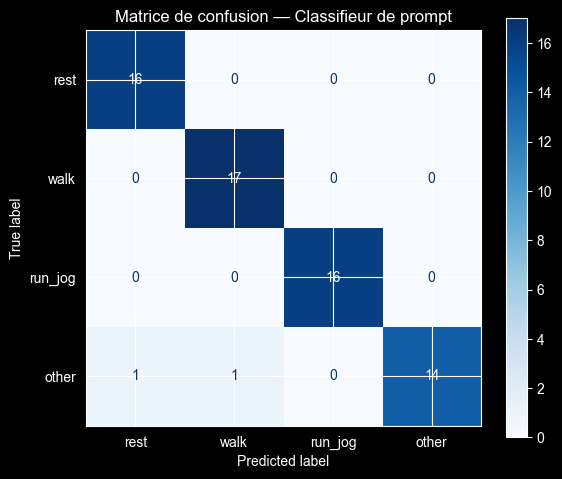

In [6]:
y_pred = clf.predict(X_test)
report = classification_report(y_test, y_pred, target_names=LABEL_NAMES)
print("── Rapport de classification ─────────────────────")
print(report)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=LABEL_NAMES,
    cmap="Blues", ax=ax,
)
ax.set_title("Matrice de confusion — Classifieur de prompt")
plt.tight_layout()
plt.savefig("prompt_classifier_confusion.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Sauvegarde du classifieur

In [7]:
joblib.dump(clf, MODEL_PATH)
log.info("Classifieur sauvegardé → %s", MODEL_PATH)

# ── Sauvegarde du mapping également, pour ne pas le redéfinir à l'inférence ──
import json
with open(OUTPUT_DIR / "prompt_label_mapping.json", "w", encoding="utf-8") as f:
    json.dump({"label_mapping": LABEL_MAPPING, "inv_mapping": {str(k): v for k, v in INV_MAPPING.items()}}, f, indent=2)

print(f"✅ Sauvegardé dans ./{OUTPUT_DIR}/ :")
print(f"  - {MODEL_PATH.name}")
print(f"  - prompt_label_mapping.json")


23:10:47 [INFO] Classifieur sauvegardé → saved_models\prompt_classifier.pkl


✅ Sauvegardé dans ./saved_models/ :
  - prompt_classifier.pkl
  - prompt_label_mapping.json


## 8. Test rapide d'inférence

In [8]:
def classify_prompt(prompt: str):
    emb   = embed([prompt]).numpy()
    pred  = clf.predict(emb)[0]
    probs = clf.predict_proba(emb)[0]
    label      = INV_MAPPING[pred]
    confidence = float(probs[pred])
    return label, confidence

for sample in [
    "I want to go for a run in the park",
    "I am lying in bed",
    "Someone is walking to the store",
    "I am riding a bicycle",
]:
    label, confidence = classify_prompt(sample)
    print(f"{sample!r:<45} → {label:<10} (conf={confidence:.3f})")


'I want to go for a run in the park'          → run_jog    (conf=0.721)
'I am lying in bed'                           → rest       (conf=0.720)
'Someone is walking to the store'             → walk       (conf=0.923)
'I am riding a bicycle'                       → other      (conf=0.693)
